In [29]:
import duckdb
import pandas as pd

from src.network import Network

DB_PATH = "data/network.duckdb"
network = Network(DB_PATH)

Generating contraction hierarchies with 1 threads.
Setting CH node vector of size 6782
Setting CH edge vector of size 14016
Range graph removed 14024 edges of 28032
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%
 100% Generating contraction hierarchies with 1 threads.
Setting CH node vector of size 6782
Setting CH edge vector of size 14016
Range graph removed 14024 edges of 28032
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%
 100% 

## Routing examples

All coordinates are in the network's CRS (`network.crs`, currently EPSG:25830 / UTM 30N meters).

In [30]:
print(f"Nodes: {len(network.nodes):,}")
print(f"Edges: {len(network.edges):,}")
print(f"CRS:   {network.crs}")
print(f"x range: {network.nodes['x'].min():,.1f}  ->  {network.nodes['x'].max():,.1f}")
print(f"y range: {network.nodes['y'].min():,.1f}  ->  {network.nodes['y'].max():,.1f}")
network.nodes.head()

Nodes: 6,782
Edges: 14,016
CRS:   EPSG:25830
x range: 691,700.9  ->  704,580.6
y range: 4,810,014.9  ->  4,825,032.0


,x,y
index,,
0,699208.2,4824034.9
1,699185.3,4824059.2
2,699246.5,4823994.1
3,699241.1,4823999.8
4,699232.9,4824007.9


In [31]:
import networkx as nx
import numpy as np

g = nx.from_pandas_edgelist(network.edges, source='from', target='to')
components = sorted(nx.connected_components(g), key=len, reverse=True)
print(f"{len(components)} components; sizes (top 10): {[len(c) for c in components[:10]]}")

# Work inside the largest component so a route is guaranteed.
biggest = list(components[0])
sub = network.nodes.loc[biggest]

# "Dense part" = top 20% of grid cells by node count.
N_BINS = 15
xbin = pd.cut(sub['x'], bins=N_BINS, labels=False)
ybin = pd.cut(sub['y'], bins=N_BINS, labels=False)
cell = pd.Series(list(zip(xbin, ybin)), index=sub.index)
counts_per_cell = cell.value_counts()
n_top = max(1, int(len(counts_per_cell) * 0.20))
dense_cells = set(counts_per_cell.head(n_top).index)
candidates = sub.index[cell.isin(dense_cells)].to_numpy()
print(f"Picking from {len(candidates)} nodes in the {n_top} densest cells")

# Keep sampling pairs until the primary and alternate routes diverge,
# so the comparison plot below is actually interesting. `for/else` runs
# the else branch only if the loop never breaks.
rng = np.random.default_rng()
MAX_ATTEMPTS = 200
for attempt in range(MAX_ATTEMPTS):
    o_id, d_id = rng.choice(candidates, size=2, replace=False)
    origin      = (network.nodes.at[o_id, 'x'], network.nodes.at[o_id, 'y'])
    destination = (network.nodes.at[d_id, 'x'], network.nodes.at[d_id, 'y'])
    primary_nodes   = network.route(origin, destination, alternate=False)
    alternate_nodes = network.route(origin, destination, alternate=True)
    if primary_nodes is None or alternate_nodes is None:
        continue
    if not np.array_equal(primary_nodes, alternate_nodes):
        print(f"Found diverging routes after {attempt + 1} attempt(s)")
        break
else:
    print(f"No diverging pair found in {MAX_ATTEMPTS} attempts; using last pair.")

origin_node, destination_node = int(o_id), int(d_id)
route = network.route_gdf(origin, destination)
print(f"Route length: {route['distance'].sum():,.0f} m  ({len(route)} edges)")


3 components; sizes (top 10): [6741, 21, 20]
Picking from 3939 nodes in the 14 densest cells
Found diverging routes after 5 attempt(s)
Route length: 974 m  (47 edges)


In [32]:
# `route` returns the shortest-path node id sequence.
node_ids = network.route(origin, destination)
print(f"Route has {len(node_ids)} nodes")
node_ids[:10]

Route has 48 nodes


array([ 121,  120,  119,  118,  117, 4519, 4535, 4630, 4629, 2192])

In [33]:
# `route_gdf` returns the same path as a GeoDataFrame of edges, ready to plot.
route = network.route_gdf(origin, destination)
total_m = float(route['distance'].sum())
print(f"Route length: {total_m:,.0f} m  ({len(route)} edges)")
route.head()

Route length: 974 m  (47 edges)


,from,to,distance,geometry,width,accesibility,alt_distance
345,121,120,4.956735,"LINESTRING (699702.961 4824304.427, 699699.65 ...",2.40000,1,0.495674
341,120,119,2.791027,"LINESTRING (699699.65 4824300.738, 699697.788 ...",2.40000,1,0.279103
339,119,118,37.008432,"LINESTRING (699697.788 4824298.659, 699673.038...",2.40000,1,3.700843
333,118,117,3.746970,"LINESTRING (699673.038 4824271.144, 699670.533...",2.40000,1,0.374697
334,117,4519,40.890165,"LINESTRING (699635.516 4824289.471, 699670.533...",5.63859,1,4.089016


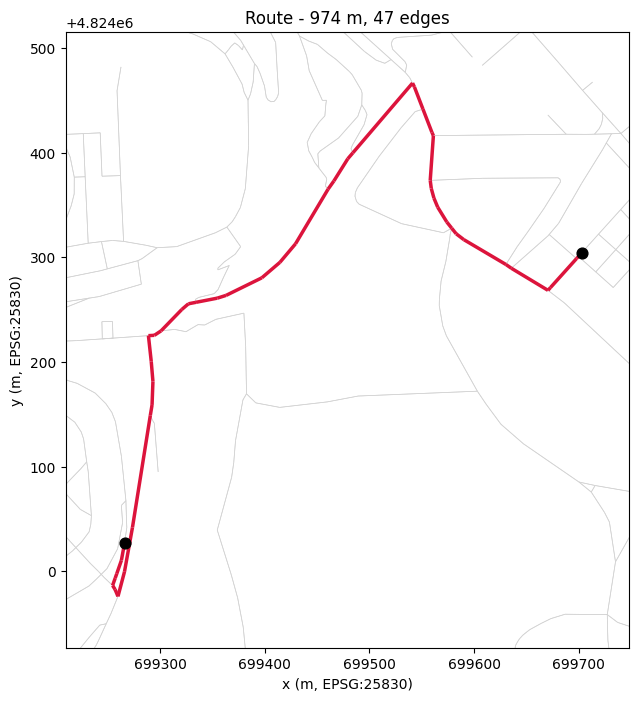

In [34]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Reconstruct every edge geometry once so we can draw the full network as backdrop.
all_edges = network.edges.copy()
all_edges['geometry'] = all_edges.apply(network.get_linestring, axis=1)
all_edges = gpd.GeoDataFrame(all_edges, geometry='geometry', crs=network.crs)

endpoints = gpd.GeoDataFrame(
    {'kind': ['origin', 'destination']},
    geometry=[Point(*origin), Point(*destination)],
    crs=network.crs,
)

fig, ax = plt.subplots(figsize=(8, 8))
all_edges.plot(ax=ax, color='lightgrey', linewidth=0.5)
route.plot(ax=ax, color='crimson', linewidth=2.5)
endpoints.plot(ax=ax, color='black', markersize=60, zorder=5)

# Zoom to the route bbox with a 10% margin so context is still visible.
minx, miny, maxx, maxy = route.total_bounds
mx, my = (maxx - minx) * 0.10, (maxy - miny) * 0.10
ax.set_xlim(minx - mx, maxx + mx)
ax.set_ylim(miny - my, maxy + my)

ax.set_aspect('equal')
ax.set_title(f"Route - {total_m:,.0f} m, {len(route)} edges")
ax.set_xlabel("x (m, EPSG:25830)")
ax.set_ylabel("y (m, EPSG:25830)")
plt.show()

distance      : 974 m, 47 edges
alt_distance  : 1,029 m, 54 edges


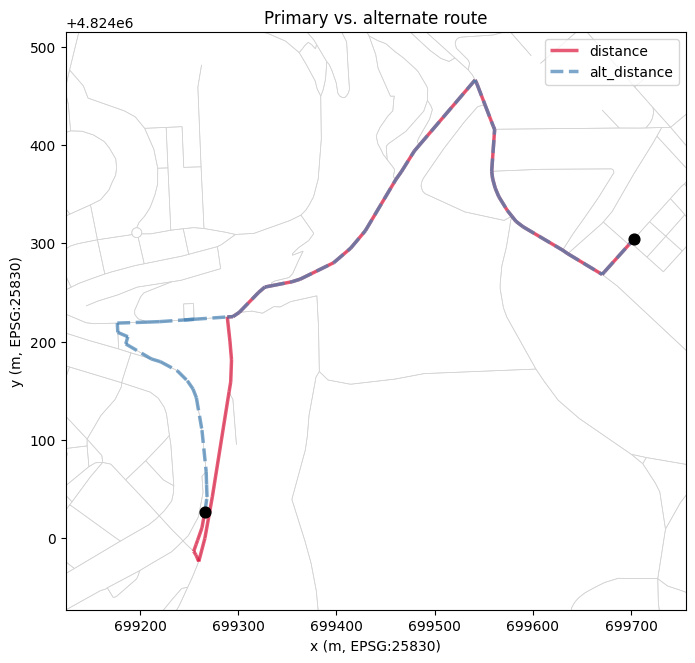

In [35]:
# Compare the two networks. With the current placeholder `alt_distance = distance`
# the two routes will be identical - once accessibility scoring is wired in,
# `alternate=True` will start preferring wider sidewalks.
primary = network.route_gdf(origin, destination, alternate=False)
alternate = network.route_gdf(origin, destination, alternate=True)

print(f"distance      : {primary['distance'].sum():,.0f} m, {len(primary)} edges")
print(f"alt_distance  : {alternate['distance'].sum():,.0f} m, {len(alternate)} edges")

fig, ax = plt.subplots(figsize=(8, 8))
all_edges.plot(ax=ax, color='lightgrey', linewidth=0.5)
primary.plot(ax=ax, color='crimson', linewidth=2.5, label='distance', alpha=0.7)
alternate.plot(ax=ax, color='steelblue', linewidth=2.5, linestyle='--', label='alt_distance', alpha=0.7)
endpoints.plot(ax=ax, color='black', markersize=60, zorder=5)

# Zoom to the union of both routes.
b1, b2 = primary.total_bounds, alternate.total_bounds
minx, miny = min(b1[0], b2[0]), min(b1[1], b2[1])
maxx, maxy = max(b1[2], b2[2]), max(b1[3], b2[3])
mx, my = (maxx - minx) * 0.10, (maxy - miny) * 0.10
ax.set_xlim(minx - mx, maxx + mx)
ax.set_ylim(miny - my, maxy + my)

ax.set_aspect('equal')
ax.legend()
ax.set_title("Primary vs. alternate route")
ax.set_xlabel("x (m, EPSG:25830)")
ax.set_ylabel("y (m, EPSG:25830)")
plt.show()